# Compare models

In [ ]:
"""
run_evaluation.py  —  Driver script for SIENA-IH-STORM evaluation
==================================================================

Edit the paths in the CONFIG section below, then run:

    python run_evaluation.py

Produces:
  1.  summary_metrics.csv        — scalar comparison table (Table-ready)
  2.  Per-candidate print_summary output to stdout
  3.  Optional: density maps, CDF plots, RP curves  (set PLOT = True)

Requires: evaluation.py in the same directory (or on PYTHONPATH).
"""


In [10]:

import numpy as np
import pandas as pd
from pathlib import Path
from evaluation import (
    load_catalog,
    compute_all_metrics,
    assemble_all_catalog,
    compute_phase_fractions,
    return_periods_at_cities,
    print_summary,
)


In [11]:

# ═══════════════════════════════════════════════════════════════════════
# CONFIG — edit these paths to match your filesystem
# ═══════════════════════════════════════════════════════════════════════

BASIN = "NA"  # Primary analysis basin

# Root directories for each candidate  ×  phase
# Each folder should contain files like:
#   STORM_DATA_IBTRACS_{basin}_{phase}_1000_YEARS_{0..9}.txt
# For B0 (no phase):
#   STORM_DATA_IBTRACS_{basin}_1000_YEARS_{0..9}.txt

DATA_ROOT = Path("/home/mbaldacchino/data")

CANDIDATES = {
    "B0": {
        # B0 has no ENSO conditioning → single folder, no phase in filename
        "ALL": {
            "folder": str(DATA_ROOT / "STORM_WW_1980_2018_climatology/STORMV4"),
            "phase": None,
        },
    },
    "B1": {
        "EN": {
            "folder": str(
                DATA_ROOT / "STORM_ENSO/IB1980-2021ELNINO/IB1980-2021ELNINO_nanfilled"
            ),
            "phase": None,
        },
        "NEU": {
            "folder": str(
                DATA_ROOT
                / "STORM_ENSO/IB1980-2021ENSO_NEUTRAL/IB1980-2021ENSO_NEUTRAL_nanfilled"
            ),
            "phase": None,
        },
        "LN": {
            "folder": str(
                DATA_ROOT / "STORM_ENSO/IB1980-2021LANINA/IB1980-2021LANINA_nanfilled"
            ),
            "phase": None,
        },
    },
    # "S1": {
    #     "EN": {"folder": str(DATA_ROOT / "SIENA_S1"), "phase": "EN"},
    #     "NEU": {"folder": str(DATA_ROOT / "SIENA_S1"), "phase": "NEU"},
    #     "LN": {"folder": str(DATA_ROOT / "SIENA_S1"), "phase": "LN"},
    # },
    # "S2": {
    #     "EN": {"folder": str(DATA_ROOT / "SIENA_S2"), "phase": "EN"},
    #     "NEU": {"folder": str(DATA_ROOT / "SIENA_S2"), "phase": "NEU"},
    #     "LN": {"folder": str(DATA_ROOT / "SIENA_S2"), "phase": "LN"},
    # },
    "S3": {
        "EN": {"folder": str(DATA_ROOT / "ENSO-STORM-SIENA/ELNINO"), "phase": None},
        "NEU": {"folder": str(DATA_ROOT / "ENSO-STORM-SIENA/NEUTRAL"), "phase": None},
        "LN": {"folder": str(DATA_ROOT / "ENSO-STORM-SIENA/LANINA"), "phase": None},
    },
}

N_YEARS_PER_PHASE = 10_000  # 10 files × 1000 yr each
N_YEARS_ALL = 10_000  # composite ALL catalog length

# Reference IBTrACS catalog  (optional — if you have it in STORM .txt format)
# Set to None if you don't have a reference in STORM format.
# You can also load IBTrACS via CLIMADA and convert, see note at bottom.
REF_FOLDER = None  # e.g. str(DATA_ROOT / "IBTRACS_STORM_FORMAT")
REF_PHASE = None
REF_N_YEARS = 42  # 1980–2021

PLOT = True  # Set True to generate plots (requires matplotlib)
OUTDIR = Path("evaluation_output")

# Return period targets
TARGET_RP = np.array([2, 5, 10, 25, 50, 100, 250, 500, 1000, 2000, 5000])



In [12]:

# ═══════════════════════════════════════════════════════════════════════
# MAIN
# ═══════════════════════════════════════════════════════════════════════


OUTDIR.mkdir(exist_ok=True)

# Load reference if provided
ref_cat = None
if REF_FOLDER:
    print("Loading reference catalog ...")
    ref_cat = load_catalog(REF_FOLDER, BASIN, phase=REF_PHASE)
    print(f"  Reference: {ref_cat['global_storm_uid'].nunique()} storms")

# Phase fractions for ALL assembly
fracs = compute_phase_fractions(BASIN)
print(f"\nPhase fractions ({BASIN}): {fracs}")

all_summary_rows = []

for cand_name, phase_specs in CANDIDATES.items():
    print(f"\n{'─' * 60}")
    print(f"  Candidate: {cand_name}")
    print(f"{'─' * 60}")

    # ── Per-phase metrics ──
    phase_catalogs = {}
    for phase_label, spec in phase_specs.items():
        if phase_label == "ALL":
            # B0: single agnostic catalog
            cat,files = load_catalog(spec["folder"], BASIN, phase=spec["phase"])
            n_yrs = N_YEARS_PER_PHASE
        else:
            cat, files= load_catalog(spec["folder"], BASIN, phase=spec["phase"])
            n_yrs = N_YEARS_PER_PHASE
            phase_catalogs[phase_label] = (cat, spec)

        print(
            f"\n  Phase={phase_label}: {cat['global_storm_uid'].nunique()} storms, "
            f"{len(cat)} rows"
        )

        m = compute_all_metrics(
            cat,
            n_yrs,
            basin=BASIN,
            reference=ref_cat,
            ref_n_years=REF_N_YEARS,
            target_rp=TARGET_RP,
            file_paths=files
        )
        print_summary(m, label=f"{cand_name} / {phase_label}")

        # Collect scalar row
        row = {
            "candidate": cand_name,
            "phase": phase_label,
            "genesis_mean": m["genesis_count"]["mean"],
            "genesis_std": m["genesis_count"]["std"],
            "total_storms": m["genesis_count"]["total_storms"],
            "lifetime_hours": m["lifetime"]["mean_hours"],
            "landfall_mean": m["landfall_counts"]["annual_mean"],
            "landfall_std": m["landfall_counts"]["annual_std"],
        }
        if "ks_pmin" in m["intensity"]:
            row["ks_pmin"] = m["intensity"]["ks_pmin"]
            row["ks_vmax"] = m["intensity"]["ks_vmax"]
        all_summary_rows.append(row)

        # Optional plots
        if PLOT:
            import matplotlib.pyplot as plt
            from evaluation import (
                plot_intensity_cdfs,
                plot_density_map,
                plot_return_period_curves,
            )

            # Intensity CDFs
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
            plot_intensity_cdfs(
                m["intensity"], f"  [{cand_name}/{phase_label}]", ax1, ax2
            )
            fig.savefig(
                OUTDIR / f"cdf_{cand_name}_{phase_label}.png",
                dpi=150,
                bbox_inches="tight",
            )
            plt.close(fig)

            # Genesis density
            gd = m["genesis_density"]
            fig, ax = plt.subplots(figsize=(10, 5))
            plot_density_map(
                gd["density"],
                gd["lon_edges"],
                gd["lat_edges"],
                title=f"Genesis density [{cand_name}/{phase_label}]",
                ax=ax,
            )
            fig.savefig(
                OUTDIR / f"genesis_{cand_name}_{phase_label}.png",
                dpi=150,
                bbox_inches="tight",
            )
            plt.close(fig)

    # ── Assemble ALL catalog (for candidates with ENSO phases) ──
    if len(phase_catalogs) == 3 and set(phase_catalogs.keys()) == {
        "EN",
        "NEU",
        "LN",
    }:
        print(f"\n  Assembling ALL catalog for {cand_name} ...")
        phase_folders = {}
        for ph, (_, spec) in phase_catalogs.items():
            phase_folders[ph] = spec["folder"]

        all_cat, files = assemble_all_catalog(
            phase_folders,
            BASIN,
            total_years=N_YEARS_ALL,
        )
        print(f"  ALL: {all_cat['global_storm_uid'].nunique()} storms")

        m_all = compute_all_metrics(
            all_cat,
            N_YEARS_ALL,
            basin=BASIN,
            reference=ref_cat,
            ref_n_years=REF_N_YEARS,
            target_rp=TARGET_RP,
            file_paths=files
        )
        print_summary(m_all, label=f"{cand_name} / ALL")

        row_all = {
            "candidate": cand_name,
            "phase": "ALL",
            "genesis_mean": m_all["genesis_count"]["mean"],
            "genesis_std": m_all["genesis_count"]["std"],
            "total_storms": m_all["genesis_count"]["total_storms"],
            "lifetime_hours": m_all["lifetime"]["mean_hours"],
            "landfall_mean": m_all["landfall_counts"]["annual_mean"],
            "landfall_std": m_all["landfall_counts"]["annual_std"],
        }
        if "ks_pmin" in m_all["intensity"]:
            row_all["ks_pmin"] = m_all["intensity"]["ks_pmin"]
            row_all["ks_vmax"] = m_all["intensity"]["ks_vmax"]
        all_summary_rows.append(row_all)

# ── Save summary CSV ──
summary_df = pd.DataFrame(all_summary_rows)
csv_path = OUTDIR / "summary_metrics.csv"
summary_df.to_csv(csv_path, index=False, float_format="%.4f")
print(f"\n{'═' * 60}")
print(f"  Summary saved to {csv_path}")
print(f"{'═' * 60}")
print(summary_df.to_string(index=False))




Phase fractions (NA): {'EN': np.float64(0.2222222222222222), 'NEU': np.float64(0.5476190476190477), 'LN': np.float64(0.23015873015873015)}

────────────────────────────────────────────────────────────
  Candidate: B0
────────────────────────────────────────────────────────────

  Phase=ALL: 107063 storms, 3424299 rows
  basin         city   lat   lon   2         5         10         25  \
0    NA        Miami  25.8 -80.2 NaN  19.01552  26.472921  35.960067   
1    NA      Houston  29.8 -95.4 NaN       NaN  19.056967  27.675355   
2    NA  New Orleans  30.0 -90.1 NaN       NaN  21.609113  29.821623   
3    NA        Tampa  28.0 -82.5 NaN       NaN  24.010159  33.592641   
4    NA     New York  40.7 -74.0 NaN       NaN        NaN  20.851042   
5    NA   Charleston  32.8 -80.0 NaN       NaN  22.037638  31.552315   

          50        100        250        500       1000       2000       5000  
0  42.205565  47.472334  53.188431  56.178119  58.297500  60.447616  62.000000  
1  33.187577

# Plot result

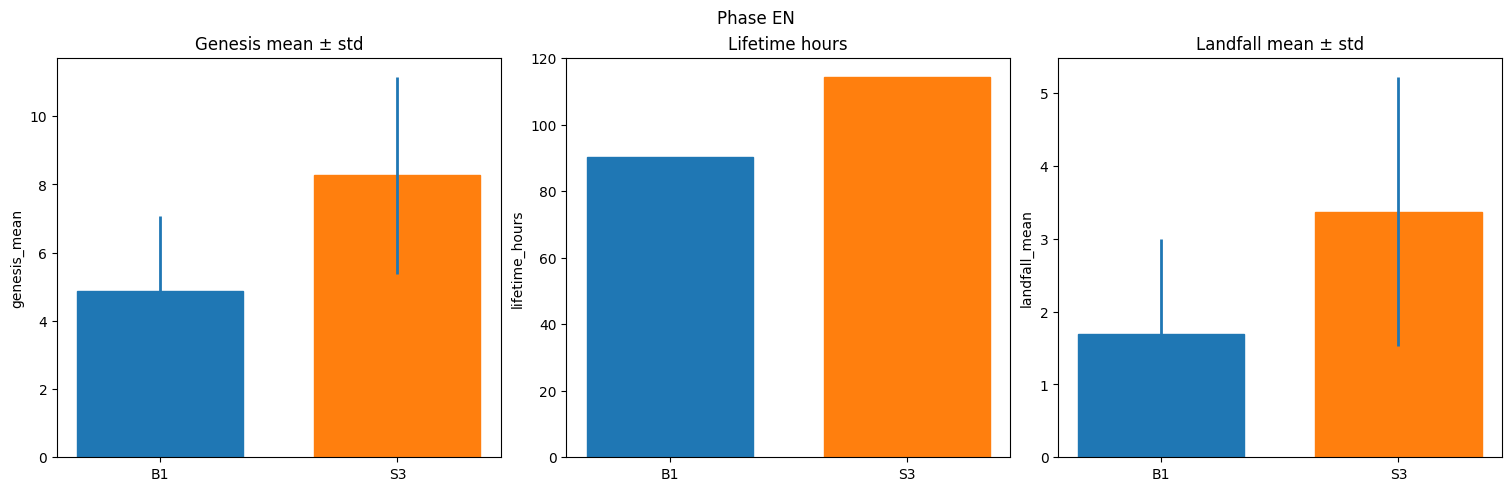

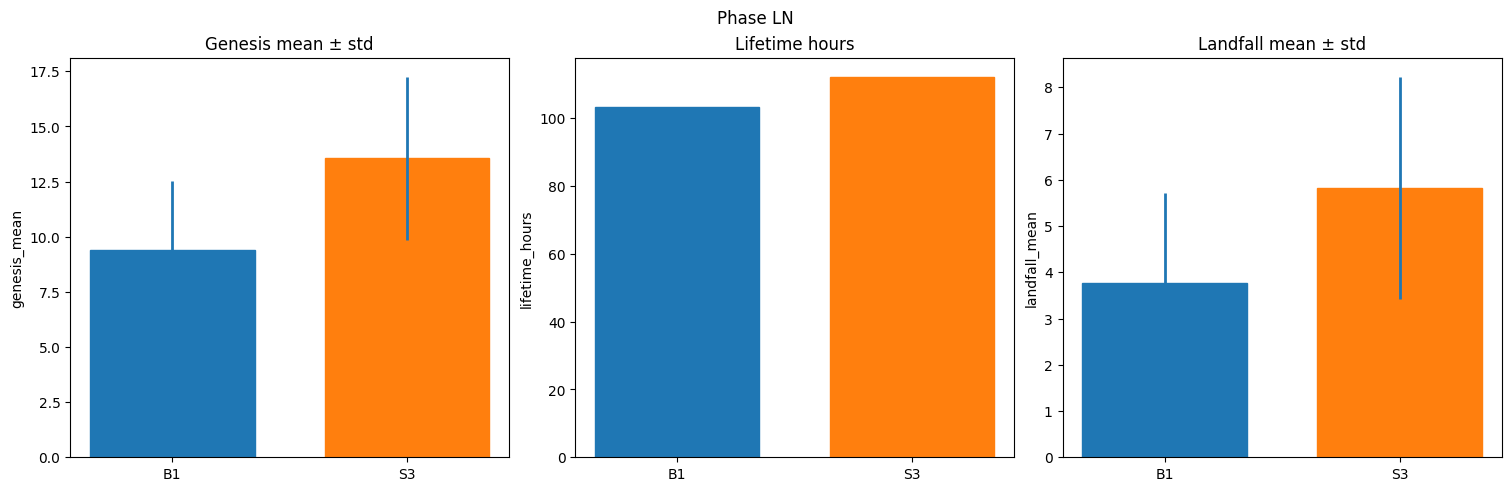

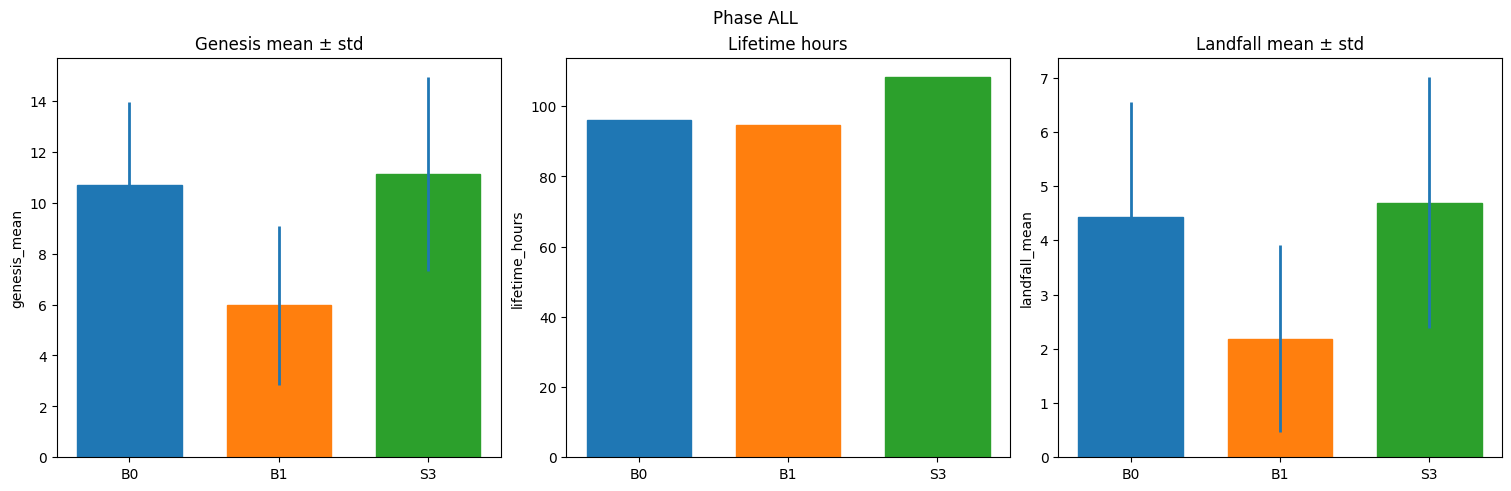

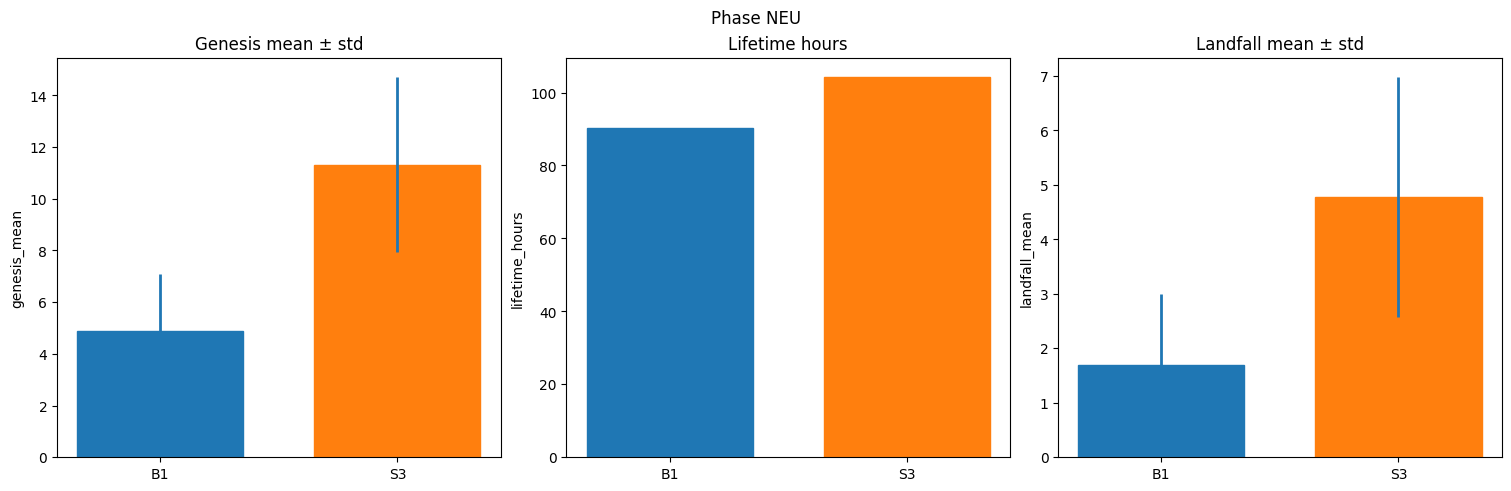

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Replace with your actual file path
df = pd.read_csv("evaluation_output/summary_metrics.csv")

phase_order = ["EN", "LN", "ALL", "NEU"]

for phase in phase_order:
    sub = df[df["phase"] == phase].copy()
    if sub.empty:
        continue

    candidates = sub["candidate"].tolist()
    x = np.arange(len(candidates))

    # default matplotlib colors, one per candidate
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"][: len(candidates)]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), constrained_layout=True)
    fig.suptitle(f"Phase {phase}")

    # 1) Genesis mean with std as vertical line
    ax = axes[0]
    bars = ax.bar(x, sub["genesis_mean"], width=0.7)
    for bar, c in zip(bars, colors):
        bar.set_color(c)
    ax.vlines(
        x,
        sub["genesis_mean"] - sub["genesis_std"],
        sub["genesis_mean"] + sub["genesis_std"],
        linewidth=2,
    )
    ax.set_xticks(x, candidates)
    ax.set_ylabel("genesis_mean")
    ax.set_title("Genesis mean ± std")

    # 2) Lifetime hours
    ax = axes[1]
    bars = ax.bar(x, sub["lifetime_hours"], width=0.7)
    for bar, c in zip(bars, colors):
        bar.set_color(c)
    ax.set_xticks(x, candidates)
    ax.set_ylabel("lifetime_hours")
    ax.set_title("Lifetime hours")

    # 3) Landfall mean with std as vertical line
    ax = axes[2]
    bars = ax.bar(x, sub["landfall_mean"], width=0.7)
    for bar, c in zip(bars, colors):
        bar.set_color(c)
    ax.vlines(
        x,
        sub["landfall_mean"] - sub["landfall_std"],
        sub["landfall_mean"] + sub["landfall_std"],
        linewidth=2,
    )
    ax.set_xticks(x, candidates)
    ax.set_ylabel("landfall_mean")
    ax.set_title("Landfall mean ± std")

    plt.show()
